## Problem 2 — Multiple Linear Regression
#🏠 Predict House Price

### Now let's make the problem more realistic.

## Problem Statement

#### A real-estate company wants to predict house prices using:

* area
* bedrooms
* age

## Target:

* price

### This is Multiple Linear Regression because we have multiple input variables.

In [33]:
import pandas as pd 


# import importn libery 
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

import  warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

data = {
    "area": [1000, 1200, 1500, 1800, 2000,
             2200, 2500, 2800, 3000, 3500],

    "bedrooms": [2, 2, 3, 3, 4,
                 4, 4, 5, 5, 5],

    "age": [20, 18, 15, 12, 10,
            8, 7, 5, 4, 2],

    "price": [30, 35, 45, 52, 60,
              68, 75, 85, 95, 110]
}

df = pd.DataFrame(data)

print(df)

   area  bedrooms  age  price
0  1000         2   20     30
1  1200         2   18     35
2  1500         3   15     45
3  1800         3   12     52
4  2000         4   10     60
5  2200         4    8     68
6  2500         4    7     75
7  2800         5    5     85
8  3000         5    4     95
9  3500         5    2    110


# Step 1 — Explore

In [37]:
print(df.head())
print(df.shape)
print(df.info())
print(df.describe())

   area  bedrooms  age  price
0  1000         2   20     30
1  1200         2   18     35
2  1500         3   15     45
3  1800         3   12     52
4  2000         4   10     60
(10, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   area      10 non-null     int64
 1   bedrooms  10 non-null     int64
 2   age       10 non-null     int64
 3   price     10 non-null     int64
dtypes: int64(4)
memory usage: 452.0 bytes
None
              area   bedrooms        age       price
count    10.000000  10.000000  10.000000   10.000000
mean   2150.000000   3.700000  10.100000   65.500000
std     808.633965   1.159502   6.063552   26.141708
min    1000.000000   2.000000   2.000000   30.000000
25%    1575.000000   3.000000   5.500000   46.750000
50%    2100.000000   4.000000   9.000000   64.000000
75%    2725.000000   4.750000  14.250000   82.500000
max    3500.00000

# Step 2 — Check missing values

In [40]:
df.isnull().sum()

area        0
bedrooms    0
age         0
price       0
dtype: int64

# Step 3 — Visualization

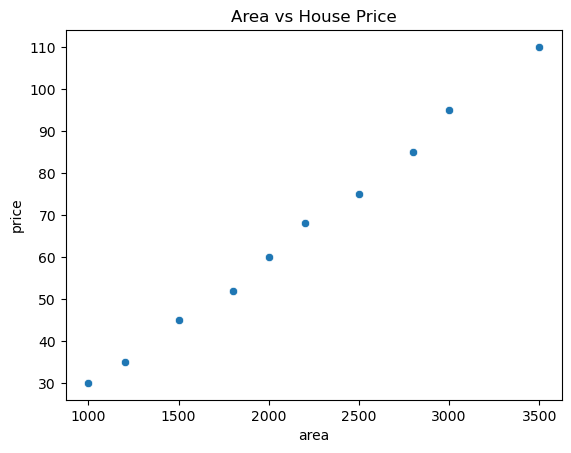

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns 

sns.scatterplot(
    x="area",
    y="price",
    data=df
)

plt.title("Area vs House Price")
plt.show()

sns.scatterplot(
    x="bedrooms",
    y="price",
    data=df
)

plt.title("Bedrooms vs House Price")
plt.show()

# Step 4 — X and y

In [48]:
X = df[
    [
        "area",
        "bedrooms",
        "age"
    ]
]

y = df["price"]

# Step 5 — Train/Test Split

In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Step 6 — Train Model

In [54]:
model = LinearRegression()

model.fit(
    X_train,
    y_train
)

LinearRegression()

# Step 7 — Predictions

In [57]:
y_pred = model.predict(X_test)

print(y_pred)

[92.67186772 35.29483   ]


# Step 8 — Evaluate

In [60]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

r2 = r2_score(
    y_test,
    y_pred
)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 1.3114811364694958
RMSE: 1.6593861256713272
R2: 0.9969404863176995


# Step 9 — Understand coefficients

In [63]:
print("Coefficients:")

for feature, coefficient in zip(
    X.columns,
    model.coef_
):
    print(feature, ":", coefficient)

print("Intercept:", model.intercept_)

Coefficients:
area : 0.03625523986958546
bedrooms : 1.0197950628784327
age : 0.7815556590591515
Intercept: -24.31904983698182


# Step 10 — Predict a new house

In [66]:
new_house = pd.DataFrame({
    "area": [2000],
    "bedrooms": [3],
    "age": [5]
})

prediction = model.predict(new_house)

print("Predicted House Price:", prediction[0])

Predicted House Price: 55.15859338612016
